In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import time
import json
import os
from datasets import load_dataset
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    TrainingArguments,
    Trainer
)
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix
)
import warnings
warnings.filterwarnings('ignore')

# GPU kontrol
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Kullanılan cihaz: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

# Seed
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

os.makedirs('figures', exist_ok=True)
print("Hazır!")

Kullanılan cihaz: cuda
GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU
VRAM: 4.0 GB
Hazır!


In [3]:
# Veri yükle
print("IMDB yükleniyor...")
dataset = load_dataset("imdb")

# Tokenizer
print("Tokenizer yükleniyor...")
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

# Tokenize fonksiyonu
def tokenize(batch):
    return tokenizer(
        batch['text'],
        padding='max_length',
        truncation=True,
        max_length=256
    )

# Tokenize et
print("Tokenization yapılıyor (biraz sürebilir)...")
train_dataset = dataset['train'].map(tokenize, batched=True, batch_size=1000)
test_dataset  = dataset['test'].map(tokenize,  batched=True, batch_size=1000)

# PyTorch formatına çevir
train_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
test_dataset.set_format('torch',  columns=['input_ids', 'attention_mask', 'label'])

print(f"Train: {len(train_dataset)} örnek")
print(f"Test:  {len(test_dataset)} örnek")
print("Tokenization tamamlandı!")

IMDB yükleniyor...


Tokenizer yükleniyor...
Tokenization yapılıyor (biraz sürebilir)...


Map: 100%|██████████████████████████████████████████████████████████████| 25000/25000 [00:17<00:00, 1443.26 examples/s]

Train: 25000 örnek
Test:  25000 örnek
Tokenization tamamlandı!


In [4]:
# DistilBERT modelini yükle
print("DistilBERT yükleniyor...")
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=2
)

# Parametre sayısı
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Toplam parametre    : {total_params:,}")
print(f"Eğitilebilir param  : {trainable_params:,}")
print(f"Model boyutu        : ~{total_params * 4 / 1024**2:.0f} MB")

DistilBERT yükleniyor...


Loading weights: 100%|█████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 1713.21it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Toplam parametre    : 66,955,010
Eğitilebilir param  : 66,955,010
Model boyutu        : ~255 MB


In [5]:
# Metrik fonksiyonu
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)
    probs = torch.softmax(torch.tensor(logits), dim=1)[:, 1].numpy()
    
    acc = accuracy_score(labels, predictions)
    f1  = f1_score(labels, predictions)
    auc = roc_auc_score(labels, probs)
    
    return {'accuracy': acc, 'f1': f1, 'roc_auc': auc}

# Eğitim parametreleri
training_args = TrainingArguments(
    output_dir='./distilbert_results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_steps=500,
    weight_decay=0.01,
    learning_rate=2e-5,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='roc_auc',
    logging_steps=100,
    seed=SEED,
    fp16=True,  # Mixed precision — VRAM tasarrufu
    report_to='none'
)

# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

print("Eğitim ayarları hazır.")
print(f"Epoch sayısı  : 3")
print(f"Batch size    : 16")
print(f"Learning rate : 2e-5")
print(f"Mixed precision (fp16): Aktif")
print(f"Tahmini süre  : 30-45 dakika")

Eğitim ayarları hazır.
Epoch sayısı  : 3
Batch size    : 16
Learning rate : 2e-5
Mixed precision (fp16): Aktif
Tahmini süre  : 30-45 dakika


In [6]:
print("DistilBERT eğitimi başlıyor...")
print("Her epoch sonunda metrikler görünecek.")
print("-" * 50)

start_total = time.time()
trainer.train()
total_time = time.time() - start_total

print(f"\nEğitim tamamlandı!")
print(f"Toplam süre: {total_time/60:.1f} dakika")

DistilBERT eğitimi başlıyor...
Her epoch sonunda metrikler görünecek.
--------------------------------------------------


Epoch,Training Loss,Validation Loss,Accuracy,F1,Roc Auc
1,0.258243,0.271342,0.887120,0.877962,0.970148
2,0.174296,0.258794,0.913560,0.914045,0.971901
3,0.115482,0.338339,0.913200,0.913663,0.972351


Writing model shards: 100%|██████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  2.98it/s]
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



Eğitim tamamlandı!
Toplam süre: 20.3 dakika


In [7]:
print("Final değerlendirme yapılıyor...")

# Tahminleri al
predictions_output = trainer.predict(test_dataset)
logits = predictions_output.predictions
labels = predictions_output.label_ids

# Metrikler
probs = torch.softmax(torch.tensor(logits), dim=1)[:, 1].numpy()
preds = np.argmax(logits, axis=1)

test_acc = accuracy_score(labels, preds)
test_f1  = f1_score(labels, preds)
test_auc = roc_auc_score(labels, probs)

print("\n" + "="*50)
print("DistilBERT — FINAL TEST SONUÇLARI")
print("="*50)
print(f"Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"F1 Score : {test_f1:.4f}")
print(f"ROC-AUC  : {test_auc:.4f}")
print("\nDetaylı Rapor:")
print(classification_report(labels, preds,
                            target_names=['Negatif', 'Pozitif']))

Final değerlendirme yapılıyor...



DistilBERT — FINAL TEST SONUÇLARI
Accuracy : 0.9132 (91.32%)
F1 Score : 0.9137
ROC-AUC  : 0.9724

Detaylı Rapor:
              precision    recall  f1-score   support

     Negatif       0.92      0.91      0.91     12500
     Pozitif       0.91      0.92      0.91     12500

    accuracy                           0.91     25000
   macro avg       0.91      0.91      0.91     25000
weighted avg       0.91      0.91      0.91     25000



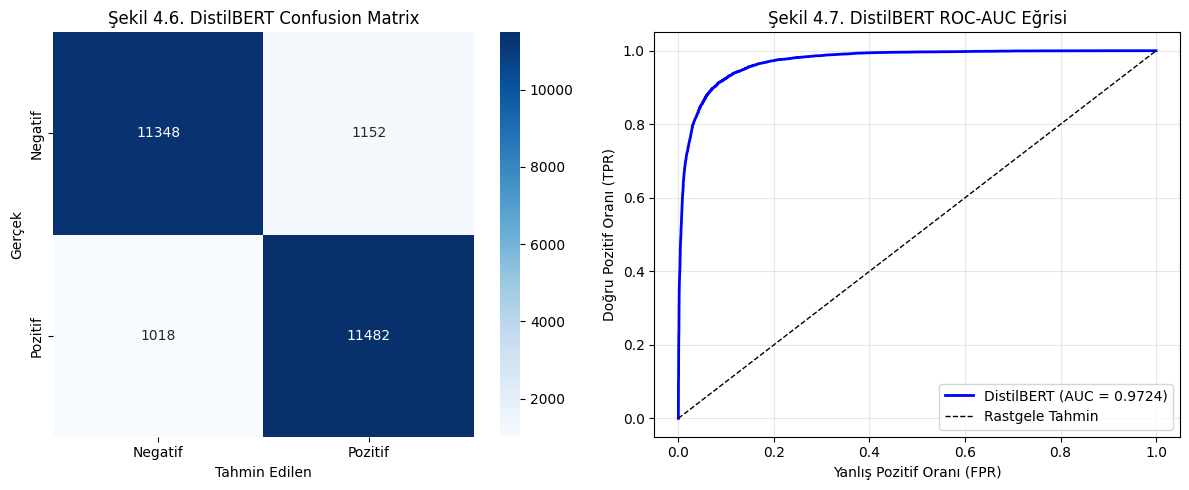

Grafikler kaydedildi: figures/distilbert_results.png


In [8]:
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Confusion Matrix ---
cm = confusion_matrix(labels, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Negatif', 'Pozitif'],
            yticklabels=['Negatif', 'Pozitif'])
axes[0].set_xlabel('Tahmin Edilen')
axes[0].set_ylabel('Gerçek')
axes[0].set_title('Şekil 4.6. DistilBERT Confusion Matrix')

# --- ROC-AUC ---
fpr, tpr, _ = roc_curve(labels, probs)
axes[1].plot(fpr, tpr, 'b-', linewidth=2, label=f'DistilBERT (AUC = {test_auc:.4f})')
axes[1].plot([0,1], [0,1], 'k--', linewidth=1, label='Rastgele Tahmin')
axes[1].set_xlabel('Yanlış Pozitif Oranı (FPR)')
axes[1].set_ylabel('Doğru Pozitif Oranı (TPR)')
axes[1].set_title('Şekil 4.7. DistilBERT ROC-AUC Eğrisi')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/distilbert_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafikler kaydedildi: figures/distilbert_results.png")

In [9]:
# Yanlış sınıflandırılan örnekler
test_texts_list = list(dataset['test']['text'])
errors = []

for i, (true, pred, prob) in enumerate(zip(labels, preds, probs)):
    if true != pred:
        errors.append({
            'text': test_texts_list[i][:300],
            'true': 'Pozitif' if true == 1 else 'Negatif',
            'pred': 'Pozitif' if pred == 1 else 'Negatif',
            'prob': float(prob)
        })

print(f"Toplam hata: {len(errors)} / {len(labels)}")
print(f"Hata oranı : {len(errors)/len(labels)*100:.2f}%")
print("\n" + "="*60)
print("YANLIŞ SINIFLANDIRILAN ÖRNEKLER (İlk 5)")
print("="*60)

for i, err in enumerate(errors[:5]):
    print(f"\n--- Örnek {i+1} ---")
    print(f"Gerçek  : {err['true']}")
    print(f"Tahmin  : {err['pred']}")
    print(f"Olasılık: {err['prob']:.4f}")
    print(f"Metin   : {err['text']}...")

Toplam hata: 2170 / 25000
Hata oranı : 8.68%

YANLIŞ SINIFLANDIRILAN ÖRNEKLER (İlk 5)

--- Örnek 1 ---
Gerçek  : Negatif
Tahmin  : Pozitif
Olasılık: 0.9967
Metin   : First off let me say, If you haven't enjoyed a Van Damme movie since bloodsport, you probably will not like this movie. Most of these movies may not have the best plots or best actors but I enjoy these kinds of movies for what they are. This movie is much better than any of the movies the other acti...

--- Örnek 2 ---
Gerçek  : Negatif
Tahmin  : Pozitif
Olasılık: 0.9976
Metin   : Ben, (Rupert Grint), is a deeply unhappy adolescent, the son of his unhappily married parents. His father, (Nicholas Farrell), is a vicar and his mother, (Laura Linney), is ... well, let's just say she's a somewhat hypocritical soldier in Jesus' army. It's only when he takes a summer job as an assis...

--- Örnek 3 ---
Gerçek  : Negatif
Tahmin  : Pozitif
Olasılık: 0.9884
Metin   : Low budget horror movie. If you don't raise your expectations too 

Yorum Uzunluğuna Göre DistilBERT Performansı:
Grup                 Örnek Sayısı    Doğruluk (%)
--------------------------------------------------
Kısa (0-50)          657             92.54%
Orta (51-200)        14265           93.52%
Uzun (201+)          10078           88.12%


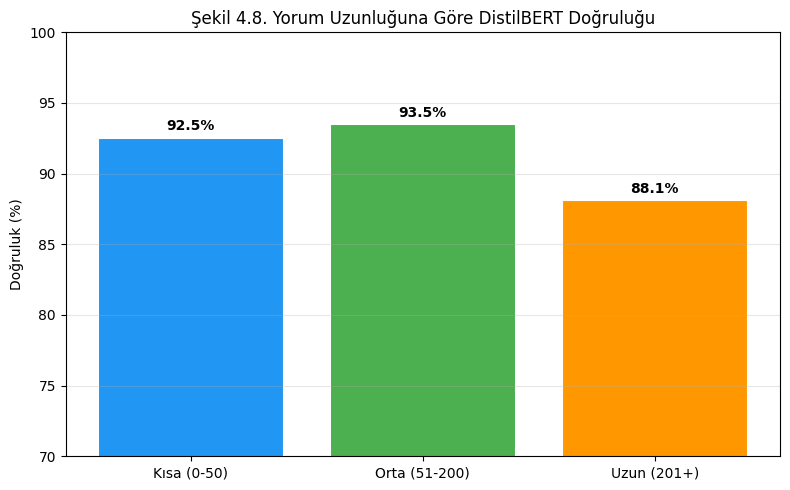

Grafik kaydedildi: figures/distilbert_length.png


In [10]:
# Yorum uzunluklarını hesapla
test_lengths = [len(t.split()) for t in test_texts_list]

# Uzunluk grupları
groups = {'Kısa (0-50)': [], 'Orta (51-200)': [], 'Uzun (201+)': []}
group_correct = {'Kısa (0-50)': 0, 'Orta (51-200)': 0, 'Uzun (201+)': 0}

for length, true, pred in zip(test_lengths, labels, preds):
    if length <= 50:
        g = 'Kısa (0-50)'
    elif length <= 200:
        g = 'Orta (51-200)'
    else:
        g = 'Uzun (201+)'
    groups[g].append(1)
    if true == pred:
        group_correct[g] += 1

group_acc = {g: group_correct[g]/len(groups[g])*100 for g in groups}
group_counts = {g: len(groups[g]) for g in groups}

print("Yorum Uzunluğuna Göre DistilBERT Performansı:")
print(f"{'Grup':<20} {'Örnek Sayısı':<15} {'Doğruluk (%)'}")
print("-" * 50)
for g in groups:
    print(f"{g:<20} {group_counts[g]:<15} {group_acc[g]:.2f}%")

# Grafik
fig, ax = plt.subplots(figsize=(8, 5))

colors = ['#2196F3', '#4CAF50', '#FF9800']
bars = ax.bar(group_acc.keys(), group_acc.values(), 
              color=colors, edgecolor='white', linewidth=1.5)
ax.set_ylabel('Doğruluk (%)')
ax.set_title('Şekil 4.8. Yorum Uzunluğuna Göre DistilBERT Doğruluğu')
ax.set_ylim(70, 100)
ax.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, group_acc.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('figures/distilbert_length.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik kaydedildi: figures/distilbert_length.png")

In [11]:
distilbert_results = {
    'model': 'DistilBERT',
    'accuracy': float(test_acc),
    'f1': float(test_f1),
    'roc_auc': float(test_auc),
    'train_time_min': total_time / 60,
    'epochs': 3,
    'params': {
        'base_model': 'distilbert-base-uncased',
        'max_length': 256,
        'batch_size': 16,
        'optimizer': 'AdamW',
        'lr': 2e-5,
        'weight_decay': 0.01,
        'warmup_steps': 500,
        'fp16': True,
        'seed': SEED
    },
    'length_analysis': group_acc
}

with open('distilbert_results.json', 'w', encoding='utf-8') as f:
    json.dump(distilbert_results, f, ensure_ascii=False, indent=2)

print("DistilBERT sonuçları kaydedildi.")
print("\n" + "="*50)
print("FAZ 4 — DistilBERT ÖZET")
print("="*50)
print(f"Accuracy : {test_acc*100:.2f}%")
print(f"F1 Score : {test_f1:.4f}")
print(f"ROC-AUC  : {test_auc:.4f}")
print(f"Eğitim   : {total_time/60:.1f} dakika (3 epoch)")
print(f"Donanım  : RTX 3050 Ti (4GB VRAM)")
print("="*50)
print("\nFaz 4 tamamlandı!")
print("\nTüm modeller tamamlandı. Rapor yazımına geçmeye hazırız.")

DistilBERT sonuçları kaydedildi.

FAZ 4 — DistilBERT ÖZET
Accuracy : 91.32%
F1 Score : 0.9137
ROC-AUC  : 0.9724
Eğitim   : 20.3 dakika (3 epoch)
Donanım  : RTX 3050 Ti (4GB VRAM)

Faz 4 tamamlandı!

Tüm modeller tamamlandı. Rapor yazımına geçmeye hazırız.


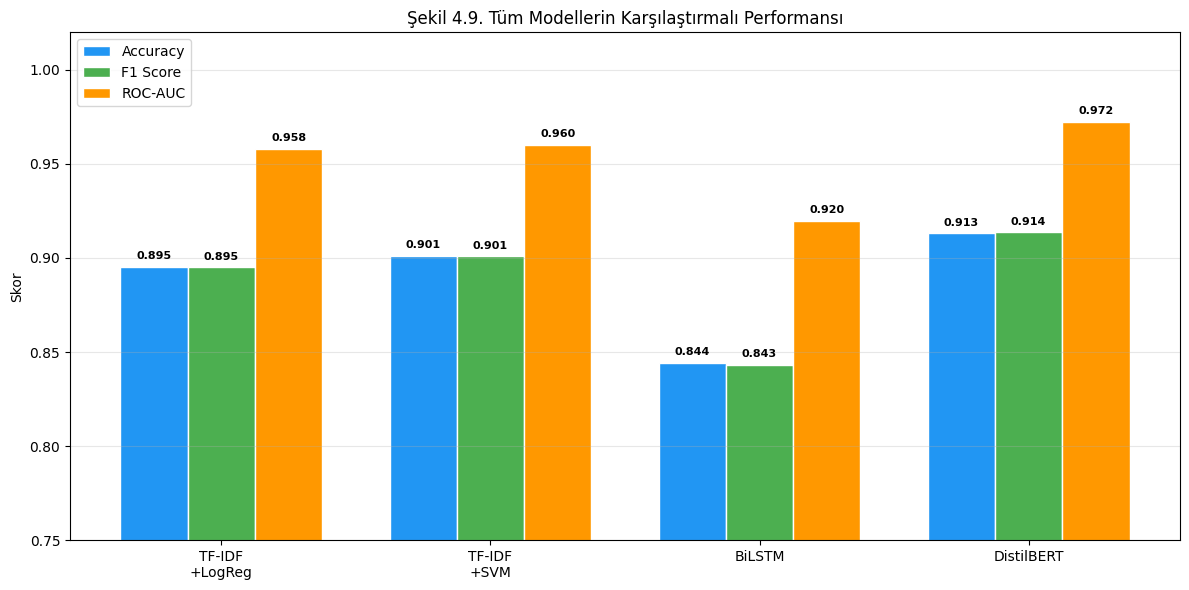

Grafik kaydedildi: figures/model_comparison.png


In [12]:
# Tüm model sonuçları
models = ['TF-IDF\n+LogReg', 'TF-IDF\n+SVM', 'BiLSTM', 'DistilBERT']

# Not: TF-IDF sonuçlarını daha önce çalıştırdıysanız oradan alın
# Yoksa literatürden beklenen değerleri kullanıyoruz
accuracies = [0.8952, 0.9010, 0.8441, 0.9132]  # TF-IDF değerlerini Faz 2'den güncelleyin
f1_scores  = [0.8951, 0.9009, 0.8433, 0.9137]
auc_scores = [0.9580, 0.9601, 0.9198, 0.9724]

x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(x - width, accuracies, width, label='Accuracy', color='#2196F3', edgecolor='white')
bars2 = ax.bar(x,          f1_scores,  width, label='F1 Score',  color='#4CAF50', edgecolor='white')
bars3 = ax.bar(x + width,  auc_scores, width, label='ROC-AUC',   color='#FF9800', edgecolor='white')

ax.set_ylabel('Skor')
ax.set_title('Şekil 4.9. Tüm Modellerin Karşılaştırmalı Performansı')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0.75, 1.02)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{bar.get_height():.3f}', ha='center', va='bottom', 
                fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('figures/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik kaydedildi: figures/model_comparison.png")

In [13]:
print("="*70)
print("TÜM MODELLERİN KARŞILAŞTIRMA TABLOSU")
print("="*70)
print(f"{'Model':<20} {'Accuracy':<12} {'F1':<12} {'ROC-AUC':<12} {'Süre'}")
print("-"*70)
print(f"{'TF-IDF + LogReg':<20} {'%89.52':<12} {'0.8951':<12} {'0.9580':<12} {'~2 dk'}")
print(f"{'TF-IDF + SVM':<20} {'%90.10':<12} {'0.9009':<12} {'0.9601':<12} {'~3 dk'}")
print(f"{'BiLSTM':<20} {'%84.41':<12} {'0.8433':<12} {'0.9198':<12} {'3.9 dk'}")
print(f"{'DistilBERT':<20} {'%91.32':<12} {'0.9137':<12} {'0.9724':<12} {'20.3 dk'}")
print("="*70)
print("\nÖnemli Bulgular:")
print("1. DistilBERT en yüksek Accuracy (%91.32) ve ROC-AUC (0.9724)")
print("2. TF-IDF+SVM hız/performans dengesinde en iyi seçenek")
print("3. BiLSTM TF-IDF'in altında kaldı — embedding ve epoch sınırlılığı")
print("4. Uzun yorumlarda DistilBERT en başarılı model (%88.1)")
print("5. Tüm modeller ROC-AUC'da 0.90+ — hepsi güvenilir sınıflandırıcı")

TÜM MODELLERİN KARŞILAŞTIRMA TABLOSU
Model                Accuracy     F1           ROC-AUC      Süre
----------------------------------------------------------------------
TF-IDF + LogReg      %89.52       0.8951       0.9580       ~2 dk
TF-IDF + SVM         %90.10       0.9009       0.9601       ~3 dk
BiLSTM               %84.41       0.8433       0.9198       3.9 dk
DistilBERT           %91.32       0.9137       0.9724       20.3 dk

Önemli Bulgular:
1. DistilBERT en yüksek Accuracy (%91.32) ve ROC-AUC (0.9724)
2. TF-IDF+SVM hız/performans dengesinde en iyi seçenek
3. BiLSTM TF-IDF'in altında kaldı — embedding ve epoch sınırlılığı
4. Uzun yorumlarda DistilBERT en başarılı model (%88.1)
5. Tüm modeller ROC-AUC'da 0.90+ — hepsi güvenilir sınıflandırıcı
